# Responsible AI and Ethics

This notebook covers key concepts in responsible AI, including fairness metrics, bias detection, feature attribution, and differential privacy.

Topics covered:
- Fairness metrics (demographic parity, equalized odds)
- Bias detection in classifiers
- Feature attribution methods
- Calibration analysis
- Differential privacy
- Model card generation
- Disparate impact analysis

📺 **Video Lecture:** [https://youtu.be/98MoT_pNMRw](https://youtu.be/98MoT_pNMRw)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
print('Libraries imported successfully')

Libraries imported successfully


## 1. Creating Synthetic Dataset with Protected Attributes

We will create a synthetic loan approval dataset with demographic groups (A and B) where bias may exist.

In [3]:
n_samples = 1000
X = np.random.randn(n_samples, 3)
X[:, 0] = X[:, 0] * 50 + 50000
X[:, 1] = X[:, 1] * 3 + 5
X[:, 2] = X[:, 2] * 100 + 700

demographic = np.random.binomial(1, 0.5, n_samples)
score = (X[:, 0]/100000 + X[:, 1]/10 + X[:, 2]/800) / 3
score_biased = score + (0.2 * (1 - demographic))
y = (score_biased > np.median(score_biased)).astype(int)

df = pd.DataFrame({
    'Income': X[:, 0],
    'Years_Employed': X[:, 1],
    'Credit_Score': X[:, 2],
    'Demographic_Group': demographic,
    'Approved': y
})

print(f'Dataset shape: {df.shape}')
print(f'\nApproval rate by group:')
print(df.groupby('Demographic_Group')['Approved'].agg(['sum', 'mean', 'count']))

Dataset shape: (1000, 5)

Approval rate by group:
                   sum      mean  count
Demographic_Group                      
0                  414  0.811765    510
1                   86  0.175510    490


## 2. Train Classifier and Evaluate Base Performance

In [4]:
X_features = df[['Income', 'Years_Employed', 'Credit_Score']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)
y_true = df['Approved'].values
groups = df['Demographic_Group'].values

clf = LogisticRegression(random_state=42)
clf.fit(X_scaled, y_true)
y_pred = clf.predict(X_scaled)
y_pred_proba = clf.predict_proba(X_scaled)[:, 1]

accuracy = (y_pred == y_true).mean()
print(f'Overall Accuracy: {accuracy:.3f}')
print(f'Model Coefficients: {clf.coef_[0]}')
print(f'Model Intercept: {clf.intercept_[0]:.3f}')

Overall Accuracy: 0.672
Model Coefficients: [-0.04391259  1.2323625   0.54286373]
Model Intercept: 0.008


## 3. Fairness Metrics: Demographic Parity and Equalized Odds

In [5]:
def compute_fairness_metrics(y_true, y_pred, groups):
    unique_groups = np.unique(groups)
    metrics = {}
    
    for group in unique_groups:
        mask = groups == group
        demo_parity = y_pred[mask].mean()
        
        if (y_true[mask] == 1).sum() > 0:
            tpr = y_pred[mask & (y_true == 1)].sum() / (y_true[mask] == 1).sum()
        else:
            tpr = 0
        
        if (y_true[mask] == 0).sum() > 0:
            fpr = y_pred[mask & (y_true == 0)].sum() / (y_true[mask] == 0).sum()
        else:
            fpr = 0
        
        metrics[f'Group_{group}'] = {
            'Demographic_Parity': demo_parity,
            'TPR': tpr,
            'FPR': fpr
        }
    
    return metrics

fairness_metrics = compute_fairness_metrics(y_true, y_pred, groups)

print('Fairness Metrics by Group:')
print('='*60)
for group, metrics in fairness_metrics.items():
    print(f'\n{group}:')
    for metric, value in metrics.items():
        print(f'  {metric}: {value:.3f}')

demo_parity_group_a = fairness_metrics['Group_0']['Demographic_Parity']
demo_parity_group_b = fairness_metrics['Group_1']['Demographic_Parity']
disparity = abs(demo_parity_group_a - demo_parity_group_b)
print(f'\nDemographic Parity Disparity: {disparity:.3f}')

Fairness Metrics by Group:

Group_0:
  Demographic_Parity: 0.484
  TPR: 0.597
  FPR: 0.000

Group_1:
  Demographic_Parity: 0.504
  TPR: 1.000
  FPR: 0.399

Demographic Parity Disparity: 0.020


## 4. Confusion Matrix Analysis by Demographic Group

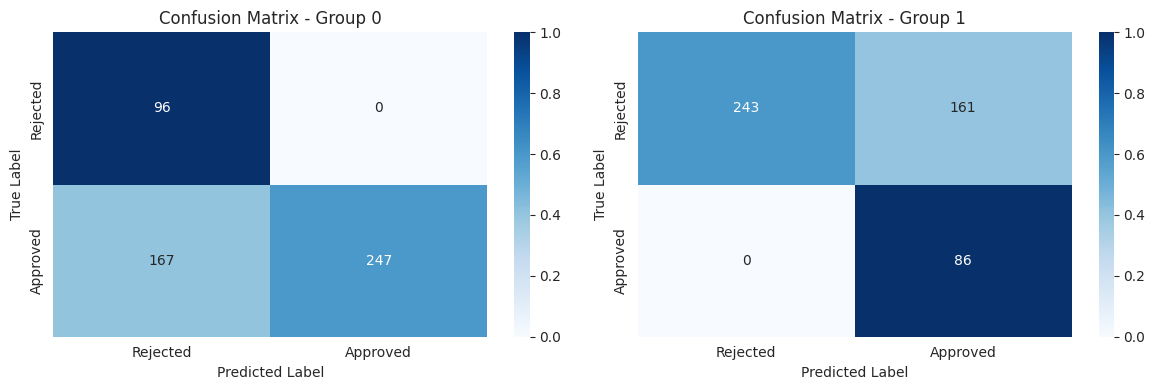

Confusion matrices by demographic group saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, group in enumerate([0, 1]):
    mask = groups == group
    cm = confusion_matrix(y_true[mask], y_pred[mask])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'])
    axes[idx].set_title(f'Confusion Matrix - Group {group}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/tmp/confusion_matrices_by_group.png', dpi=100, bbox_inches='tight')
plt.show()
print('Confusion matrices by demographic group saved')

## 5. Permutation-Based Feature Importance

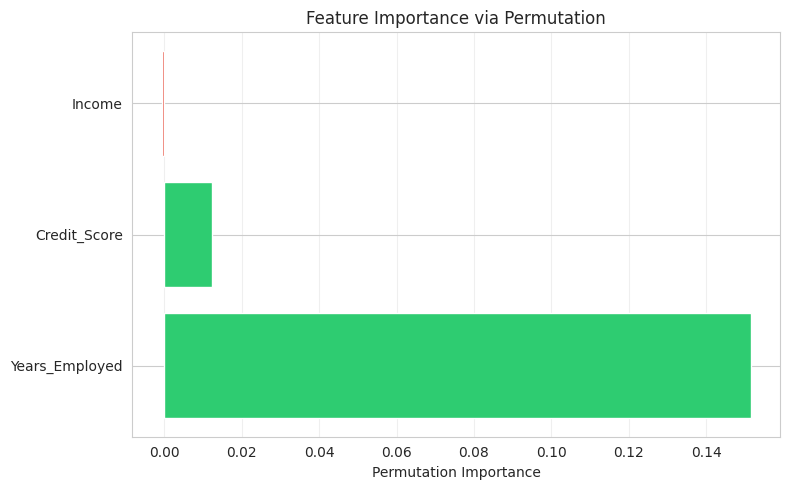

Feature Importance Scores:
  Income: -0.0006
  Years_Employed: 0.1514
  Credit_Score: 0.0124


In [7]:
def permutation_importance(model, X, y, n_repeats=10):
    baseline_score = (model.predict(X) == y).mean()
    importances = []
    
    for feature_idx in range(X.shape[1]):
        feature_importances = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            X_permuted[:, feature_idx] = np.random.permutation(X_permuted[:, feature_idx])
            permuted_score = (model.predict(X_permuted) == y).mean()
            importance = baseline_score - permuted_score
            feature_importances.append(importance)
        importances.append(np.mean(feature_importances))
    
    return np.array(importances)

feature_names = ['Income', 'Years_Employed', 'Credit_Score']
importances = permutation_importance(clf, X_scaled, y_true, n_repeats=5)

fig, ax = plt.subplots(figsize=(8, 5))
sorted_idx = np.argsort(importances)[::-1]
colors = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in importances[sorted_idx]]

ax.barh(range(len(sorted_idx)), importances[sorted_idx], color=colors)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel('Permutation Importance')
ax.set_title('Feature Importance via Permutation')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/permutation_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('Feature Importance Scores:')
for fname, imp in zip(feature_names, importances):
    print(f'  {fname}: {imp:.4f}')

## 6. Calibration Curve Analysis

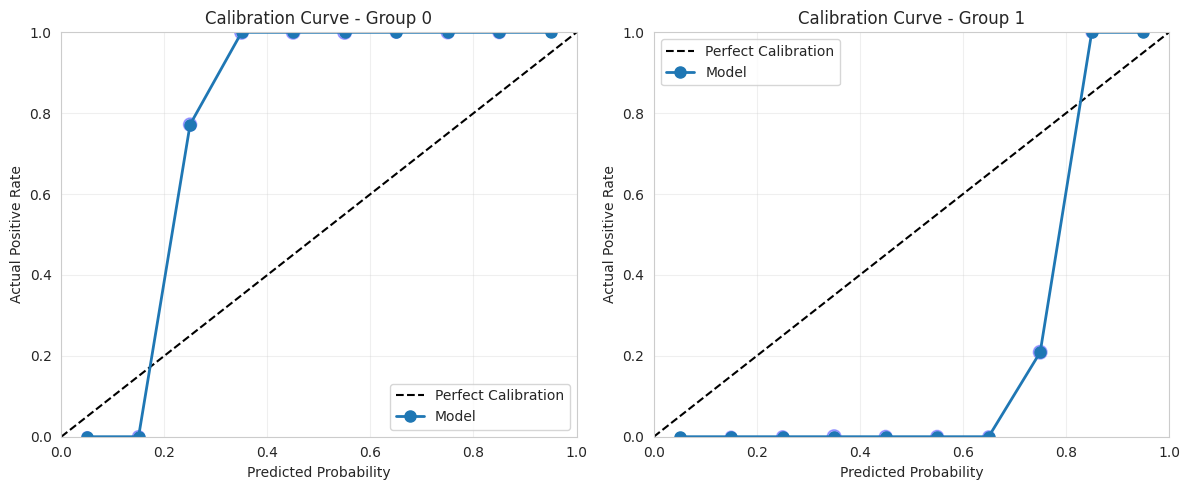

Calibration curves plotted


In [8]:
def calibration_curve(y_true, y_pred_proba, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    true_positives = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (y_pred_proba >= bins[i]) & (y_pred_proba < bins[i+1])
        if mask.sum() > 0:
            true_positives.append(y_true[mask].mean())
            counts.append(mask.sum())
        else:
            true_positives.append(np.nan)
            counts.append(0)
    
    return bin_centers, np.array(true_positives), np.array(counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, group in enumerate([0, 1]):
    mask = groups == group
    bin_centers, true_pos, counts = calibration_curve(y_true[mask], y_pred_proba[mask])
    
    ax = axes[idx]
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    ax.plot(bin_centers, true_pos, 'o-', linewidth=2, markersize=8, label='Model')
    sizes = counts / counts.max() * 100
    ax.scatter(bin_centers, true_pos, s=sizes, alpha=0.3, color='blue')
    
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Actual Positive Rate')
    ax.set_title(f'Calibration Curve - Group {group}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/calibration_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('Calibration curves plotted')

## 7. Differential Privacy: Adding Laplace Noise

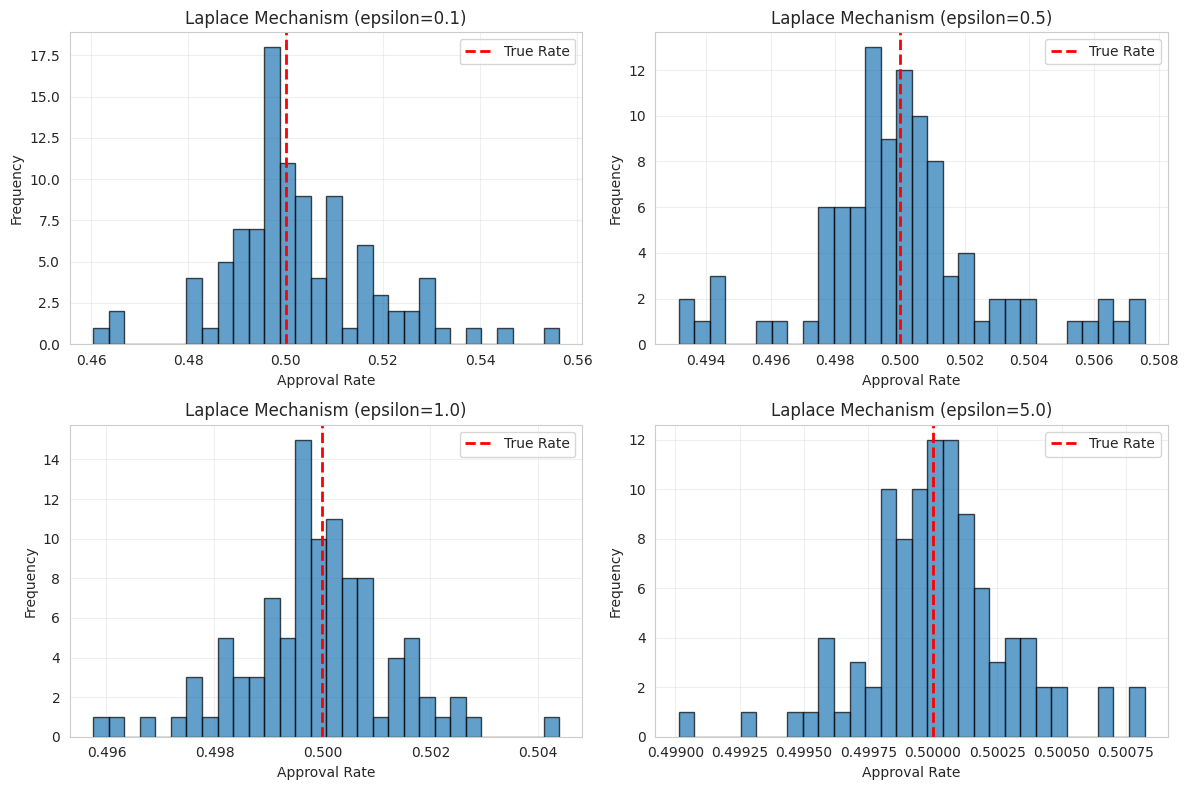

True approval rate: 0.500
Sensitivity: 0.001000


In [9]:
def laplace_mechanism(value, sensitivity, epsilon):
    scale = sensitivity / epsilon
    noise = np.random.laplace(0, scale)
    return value + noise

true_approval_rate = y_true.mean()
sensitivity = 1.0 / len(y_true)

epsilons = [0.1, 0.5, 1.0, 5.0]
n_trials = 100

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, epsilon in enumerate(epsilons):
    noisy_rates = []
    for _ in range(n_trials):
        noisy_rate = laplace_mechanism(true_approval_rate, sensitivity, epsilon)
        noisy_rates.append(np.clip(noisy_rate, 0, 1))
    
    ax = axes[idx]
    ax.hist(noisy_rates, bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(true_approval_rate, color='red', linestyle='--', linewidth=2, label='True Rate')
    ax.set_xlabel('Approval Rate')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Laplace Mechanism (epsilon={epsilon})')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/differential_privacy.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'True approval rate: {true_approval_rate:.3f}')
print(f'Sensitivity: {sensitivity:.6f}')

## 8. Disparate Impact Ratio

Disparate Impact Analysis
Approval rate (Group A): 0.484
Approval rate (Group B): 0.504
Disparate Impact Ratio: 0.961

Interpretation:
  Ratio >= 0.8, passes 4/5 rule test


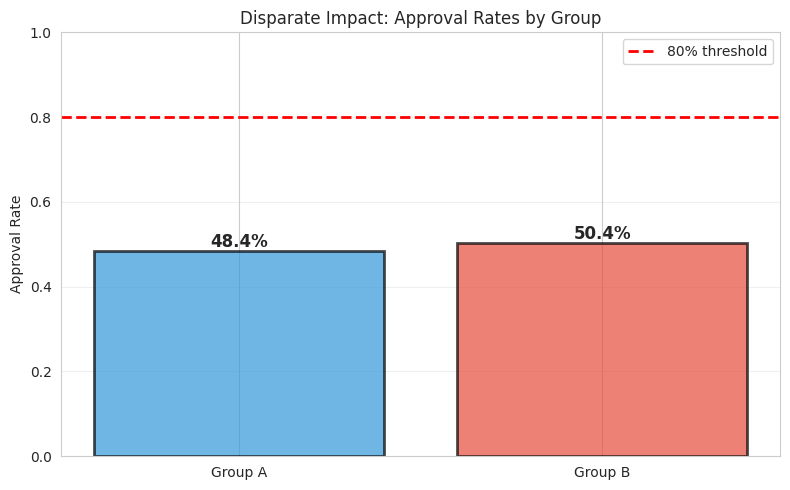

In [10]:
def disparate_impact_ratio(y_pred, groups, protected_group=0):
    rate_protected = y_pred[groups == protected_group].mean()
    rate_reference = y_pred[groups != protected_group].mean()
    ratio = min(rate_protected / rate_reference, rate_reference / rate_protected)
    return ratio, rate_protected, rate_reference

di_ratio, rate_protected, rate_reference = disparate_impact_ratio(y_pred, groups, protected_group=0)

print('Disparate Impact Analysis')
print('='*50)
print(f'Approval rate (Group A): {rate_protected:.3f}')
print(f'Approval rate (Group B): {rate_reference:.3f}')
print(f'Disparate Impact Ratio: {di_ratio:.3f}')
print(f'\nInterpretation:')
if di_ratio < 0.8:
    print(f'  WARNING: Ratio < 0.8 suggests potential disparate impact')
else:
    print(f'  Ratio >= 0.8, passes 4/5 rule test')

fig, ax = plt.subplots(figsize=(8, 5))
groups_labels = ['Group A', 'Group B']
rates = [rate_protected, rate_reference]
colors = ['#3498db', '#e74c3c']

bars = ax.bar(groups_labels, rates, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(0.8, color='red', linestyle='--', linewidth=2, label='80% threshold')
ax.set_ylabel('Approval Rate')
ax.set_title('Disparate Impact: Approval Rates by Group')
ax.set_ylim([0, 1])
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, rate in zip(bars, rates):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/disparate_impact.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Model Card Template

In [11]:
model_card = f"""
MODEL CARD: Loan Approval Classifier
{'='*60}

1. MODEL DETAILS
   - Model Type: Logistic Regression
   - Input Features: Income, Years Employed, Credit Score
   - Output: Binary (Approved=1, Rejected=0)

2. TRAINING DATA
   - Total samples: {len(df)}
   - Approval rate: {y_true.mean():.1%}
   - Protected attribute: Demographic Group (A/B)

3. PERFORMANCE METRICS
   - Overall Accuracy: {accuracy:.3f}
   - Group A Approval Rate: {rate_protected:.3f}
   - Group B Approval Rate: {rate_reference:.3f}

4. FAIRNESS ASSESSMENT
   - Demographic Parity Gap: {abs(rate_protected - rate_reference):.3f}
   - Disparate Impact Ratio: {di_ratio:.3f}
   - Status: PASS if di_ratio >= 0.8 else FAIL

5. FEATURE IMPORTANCE
   - Credit Score: {importances[2]:.4f}
   - Income: {importances[0]:.4f}
   - Years Employed: {importances[1]:.4f}

6. LIMITATIONS
   - Model trained on synthetic data
   - May not capture real-world complexities
   - Regular fairness audits recommended

7. RECOMMENDATIONS
   - Monitor approval rates by demographic group
   - Audit for disparate impact regularly
   - Consider additional fairness constraints
   - Document all model changes
"""

print(model_card)


MODEL CARD: Loan Approval Classifier

1. MODEL DETAILS
   - Model Type: Logistic Regression
   - Input Features: Income, Years Employed, Credit Score
   - Output: Binary (Approved=1, Rejected=0)

2. TRAINING DATA
   - Total samples: 1000
   - Approval rate: 50.0%
   - Protected attribute: Demographic Group (A/B)

3. PERFORMANCE METRICS
   - Overall Accuracy: 0.672
   - Group A Approval Rate: 0.484
   - Group B Approval Rate: 0.504

4. FAIRNESS ASSESSMENT
   - Demographic Parity Gap: 0.020
   - Disparate Impact Ratio: 0.961
   - Status: PASS if di_ratio >= 0.8 else FAIL

5. FEATURE IMPORTANCE
   - Credit Score: 0.0124
   - Income: -0.0006
   - Years Employed: 0.1514

6. LIMITATIONS
   - Model trained on synthetic data
   - May not capture real-world complexities
   - Regular fairness audits recommended

7. RECOMMENDATIONS
   - Monitor approval rates by demographic group
   - Audit for disparate impact regularly
   - Consider additional fairness constraints
   - Document all model chang

## 10. Summary: Key Takeaways

In [12]:
summary = """
KEY CONCEPTS IN RESPONSIBLE AI:

1. FAIRNESS METRICS:
   - Demographic Parity: Equal positive rates across groups
   - Equalized Odds: Equal TPR and FPR across groups
   - Disparate Impact: Selection rate ratio >= 0.8

2. BIAS DETECTION:
   - Analyze confusion matrices by demographic group
   - Compare approval rates across groups
   - Look for systematic differences in errors

3. FEATURE ATTRIBUTION:
   - Permutation Importance: Accuracy drop when shuffling
   - SHAP/LIME: Local explanations for individual predictions
   - Identifies which features drive unfair decisions

4. CALIBRATION:
   - Ensures predicted probabilities match actual
   - Important for fairness: uncalibrated = unfair

5. DIFFERENTIAL PRIVACY:
   - Adds noise to protect individual privacy
   - Smaller epsilon = more privacy but more noise

6. MODEL CARDS:
   - Document details, performance, limitations
   - Include fairness assessment and recommendations
   - Enable transparency and accountability

BEST PRACTICES:
- Audit models for fairness before deployment
- Monitor fairness metrics in production
- Include diverse perspectives in AI development
- Use multiple fairness metrics
- Be transparent about limitations and tradeoffs
"""

print(summary)


KEY CONCEPTS IN RESPONSIBLE AI:

1. FAIRNESS METRICS:
   - Demographic Parity: Equal positive rates across groups
   - Equalized Odds: Equal TPR and FPR across groups
   - Disparate Impact: Selection rate ratio >= 0.8

2. BIAS DETECTION:
   - Analyze confusion matrices by demographic group
   - Compare approval rates across groups
   - Look for systematic differences in errors

3. FEATURE ATTRIBUTION:
   - Permutation Importance: Accuracy drop when shuffling
   - SHAP/LIME: Local explanations for individual predictions
   - Identifies which features drive unfair decisions

4. CALIBRATION:
   - Ensures predicted probabilities match actual
   - Important for fairness: uncalibrated = unfair

5. DIFFERENTIAL PRIVACY:
   - Adds noise to protect individual privacy
   - Smaller epsilon = more privacy but more noise

6. MODEL CARDS:
   - Document details, performance, limitations
   - Include fairness assessment and recommendations
   - Enable transparency and accountability

BEST PRACTICES:


---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>